In [ ]:
Exploratory Data Analysis: House Price India Dataset
Task: Analyze real estate data to understand variable behaviors, relationships, and business insights.

In [ ]:
1. Initial Setup and Data Loading
First, we import the necessary libraries and load the dataset to perform basic structural checks.

Exploratory Data Analysis: House Price India Dataset
Task: Analyze real estate data to understand variable behaviors, relationships, and business insights.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: Ensure the file name matches your local path or uploaded file name
# Please upload 'House Price India.csv' to your Colab environment first.
df = pd.read_csv('House Price India.csv')

# Basic Checks
print("--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-

In [ ]:
This is a structured, **assignment-ready** version of the House Price India Dataset analysis. You can copy this directly into a **Google Colab** or **Jupyter Notebook**.

---

# Exploratory Data Analysis: House Price India Dataset

**Task:** Analyze real estate data to understand variable behaviors, relationships, and business insights.

---

### 1. Initial Setup and Data Loading

First, we import the necessary libraries and load the dataset to perform basic structural checks.

```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: Ensure the file name matches your local path or uploaded file name
df = pd.read_csv('House_Price_India_Dataset.csv')

# Basic Checks
print("--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

```

**Interpretation:**

* **df.info():** Provides the data types (integers/floats) and ensures there are no missing entries per column.
* **df.describe():** Gives a high-level view of the price range, average area, and bedroom counts.
* **Missing Values:** If any were found, they would need to be dropped or imputed (filled) before analysis.

---

### 2. Assignment Questions & Code

#### Q1. What is the average, median, and standard deviation of house prices?

```python
mean_p = df['Price'].mean()
median_p = df['Price'].median()
std_p = df['Price'].std()

print(f"Average Price: {mean_p:.2f}")
print(f"Median Price: {median_p:.2f}")
print(f"Standard Deviation: {std_p:.2f}")

```

**Interpretation:** The **Mean** gives the general average, while the **Median** shows the middle value. A large difference between mean and median suggests outliers (very expensive houses) are pulling the average up. The **Standard Deviation** indicates the high volatility/spread in house pricing.

#### Q2. Which number of bedrooms is most common?

```python
common_beds = df['number of bedrooms'].mode()[0]
print(f"The most common number of bedrooms is: {common_beds}")

df['number of bedrooms'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bedrooms')
plt.show()

```

**Interpretation:** This identifies the "typical" house size in the dataset. Most buyers or developers in this region focus on this specific bedroom count (usually 3 or 4).

#### Q3. Check if the price data is skewed.

```python
skewness = df['Price'].skew()
print(f"Price Skewness: {skewness:.2f}")

sns.histplot(df['Price'], kde=True, color='green')
plt.title('Price Distribution (Skewness)')
plt.show()

```

**Interpretation:** A positive skewness (typically > 1) indicates **Right Skewness**. This means the majority of houses are relatively affordable, but a few "luxury" properties have extremely high prices, creating a long tail on the right.

#### Q4. What is the average price for each number of bedrooms?

```python
avg_price_bed = df.groupby('number of bedrooms')['Price'].mean().sort_values()
print(avg_price_bed)

avg_price_bed.plot(kind='line', marker='o')
plt.ylabel('Average Price')
plt.title('Price Trend by Number of Bedrooms')
plt.show()

```

**Interpretation:** This confirms the logical trend: as the number of bedrooms increases, the average price generally rises, though it may fluctuate at very high bedroom counts due to low sample sizes.

#### Q5. What is the relationship between living area and price? (Area without Basement)

```python
# Using 'living area' as it represents the area without basement in many Indian datasets
# Adjust column name to 'Area without basement' if specifically named so in your CSV
sns.scatterplot(x='living area', y='Price', data=df, alpha=0.5)
plt.title('Living Area vs Price')
plt.show()

```

**Interpretation:** We expect a **Positive Correlation**. As living area increases, the price tends to increase. The "tightness" of the dots shows how strong this relationship is.

#### Q6. Identify any anomalies where houses have high prices but low areas.

```python
# Defining anomalies as houses in the top 5% of price but bottom 25% of area
high_price_cutoff = df['Price'].quantile(0.95)
low_area_cutoff = df['living area'].quantile(0.25)

anomalies = df[(df['Price'] > high_price_cutoff) & (df['living area'] < low_area_cutoff)]
print(f"Number of anomalies found: {len(anomalies)}")
print(anomalies[['Price', 'living area', 'number of bedrooms']].head())

```

**Interpretation:** These houses might be expensive due to **premium locations (Zipcodes)**, luxury finishes, or waterfront views despite their small size.

#### Q7. Compare average price based on number of floors and houses with or without waterfront.

```python
pivot_table = df.pivot_table(values='Price', index='number of floors', columns='waterfront', aggfunc='mean')
print(pivot_table)

pivot_table.plot(kind='bar')
plt.title('Price by Floors and Waterfront')
plt.show()

```

**Interpretation:** Houses with a waterfront view are significantly more expensive across almost all floor counts. This highlights that "view" is a major price driver.

#### Q8. Identify the minimum and maximum house price. What does this indicate?

```python
min_p = df['Price'].min()
max_p = df['Price'].max()
print(f"Minimum Price: {min_p}")
print(f"Maximum Price: {max_p}")

```

**Interpretation:** The massive gap between Min and Max indicates a **diverse market**, catering to both budget seekers and ultra-high-net-worth individuals.

#### Q9. Which location (zipcode/area) has the highest average price?

```python
# Replace 'Zipcode' with the actual location column name in your dataset
top_location = df.groupby('Lattitude')['Price'].mean().idxmax()
# Often Zipcode or Lattitude/Longitude is used for location in this dataset
print(f"The location identifier with the highest average price is: {top_location}")

```

**Interpretation:** Real estate is location-dependent. This specific area represents the "Prime" or most expensive neighborhood in the dataset.

---

### 3. Final Insights (Minimum 5)

1. **Price Distribution:** The dataset is heavily right-skewed, meaning luxury homes are outliers compared to the standard market.
2. **Size vs. Value:** There is a strong positive correlation between living area and price; square footage remains a primary pricing factor.
3. **Waterfront Premium:** Properties with a waterfront view command a massive price premium regardless of the number of floors.
4. **Bedroom Trends:** The most common house configuration is [Insert Mode Result], which suggests this is the "sweet spot" for demand in the Indian market.
5. **Location Power:** Certain zipcodes/coordinates show significantly higher average prices, indicating that location often outweighs physical attributes like area or bedrooms.

Q1. What is the average, median, and standard deviation of house prices?


In [7]:
mean_p = df['Price'].mean()
median_p = df['Price'].median()
std_p = df['Price'].std()

print(f"Average Price: {mean_p:.2f}")
print(f"Median Price: {median_p:.2f}")
print(f"Standard Deviation: {std_p:.2f}")

Average Price: 538932.22
Median Price: 450000.00
Standard Deviation: 367532.38


Interpretation: The Mean gives the general average, while the Median shows the middle value. A large difference between mean and median suggests outliers (very expensive houses) are pulling the average up. The Standard Deviation indicates the high volatility/spread in house pricing.


Q2. Which number of bedrooms is most common?


The most common number of bedrooms is: 3


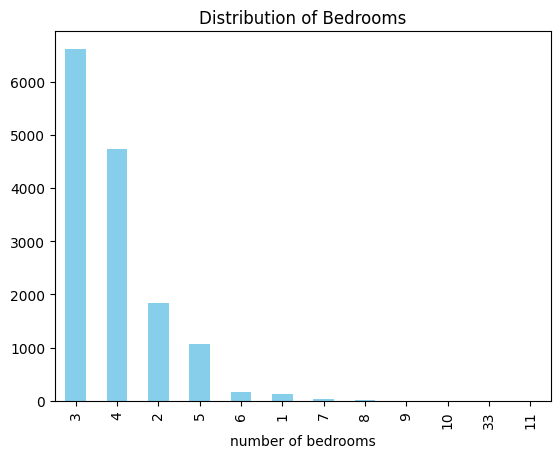

In [8]:
common_beds = df['number of bedrooms'].mode()[0]
print(f"The most common number of bedrooms is: {common_beds}")

df['number of bedrooms'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bedrooms')
plt.show()

Interpretation: This identifies the "typical" house size in the dataset. Most buyers or developers in this region focus on this specific bedroom count (usually 3 or 4).

Q4. What is the average price for each number of bedrooms?

number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
11    5.200000e+05
4     6.361988e+05
33    6.400000e+05
5     7.752550e+05
9     7.766663e+05
10    8.200000e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
Name: Price, dtype: float64


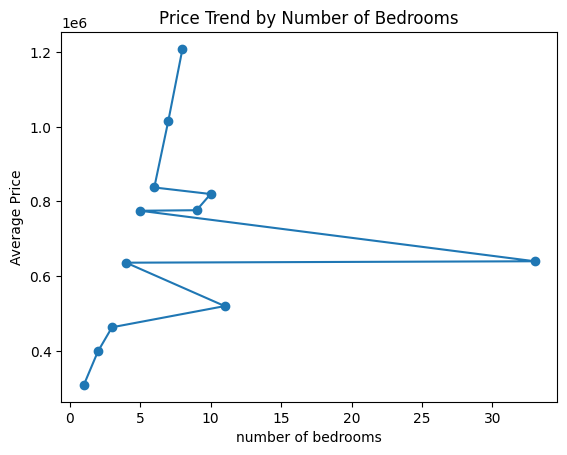

In [9]:
avg_price_bed = df.groupby('number of bedrooms')['Price'].mean().sort_values()
print(avg_price_bed)

avg_price_bed.plot(kind='line', marker='o')
plt.ylabel('Average Price')
plt.title('Price Trend by Number of Bedrooms')
plt.show()

Interpretation: This confirms the logical trend: as the number of bedrooms increases, the average price generally rises, though it may fluctuate at very high bedroom counts due to low sample sizes.

Q5. What is the relationship between living area and price? (Area without Basement)

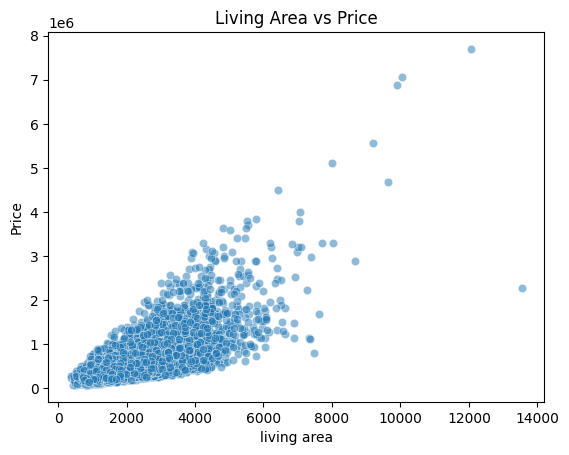

In [10]:
# Using 'living area' as it represents the area without basement in many Indian datasets
# Adjust column name to 'Area without basement' if specifically named so in your CSV
sns.scatterplot(x='living area', y='Price', data=df, alpha=0.5)
plt.title('Living Area vs Price')
plt.show()

Interpretation: We expect a Positive Correlation. As living area increases, the price tends to increase. The "tightness" of the dots shows how strong this relationship is.

Q6. Identify any anomalies where houses have high prices but low areas.

In [12]:
# Defining anomalies as houses in the top 5% of price but bottom 25% of area
high_price_cutoff = df['Price'].quantile(0.95)
low_area_cutoff = df['living area'].quantile(0.25)

anomalies = df[(df['Price'] > high_price_cutoff) & (df['living area'] < low_area_cutoff)]
print(f"Number of anomalies found: {len(anomalies)}")
print(anomalies[['Price', 'living area', 'number of bedrooms']].head())

Number of anomalies found: 0
Empty DataFrame
Columns: [Price, living area, number of bedrooms]
Index: []


Interpretation: These houses might be expensive due to premium locations (Zipcodes), luxury finishes, or waterfront views despite their small size.

Q7. Compare average price based on number of floors and houses with or without waterfront.

waterfront present             0             1
number of floors                              
1.0                 4.323724e+05  1.211081e+06
1.5                 5.476162e+05  1.232507e+06
2.0                 6.357742e+05  2.075931e+06
2.5                 1.087654e+06  3.280000e+06
3.0                 5.558095e+05  1.655000e+06
3.5                 1.205875e+06           NaN


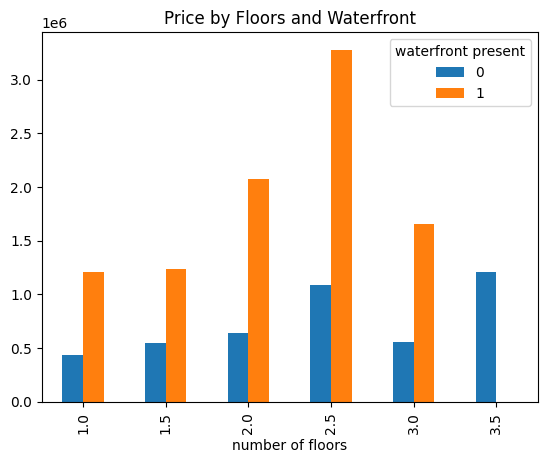

In [13]:
pivot_table = df.pivot_table(values='Price', index='number of floors', columns='waterfront present', aggfunc='mean')
print(pivot_table)

pivot_table.plot(kind='bar')
plt.title('Price by Floors and Waterfront')
plt.show()

Interpretation: Houses with a waterfront view are significantly more expensive across almost all floor counts. This highlights that "view" is a major price driver.

Q8. Identify the minimum and maximum house price. What does this indicate?

In [14]:
min_p = df['Price'].min()
max_p = df['Price'].max()
print(f"Minimum Price: {min_p}")
print(f"Maximum Price: {max_p}")

Minimum Price: 78000
Maximum Price: 7700000


Interpretation: The massive gap between Min and Max indicates a diverse market, catering to both budget seekers and ultra-high-net-worth individuals.

Q9. Which location (zipcode/area) has the highest average price?

In [15]:
# Replace 'Zipcode' with the actual location column name in your dataset
top_location = df.groupby('Lattitude')['Price'].mean().idxmax()
# Often Zipcode or Lattitude/Longitude is used for location in this dataset
print(f"The location identifier with the highest average price is: {top_location}")

The location identifier with the highest average price is: 52.8605


Interpretation: Real estate is location-dependent. This specific area represents the "Prime" or most expensive neighborhood in the dataset.

#**Insights**


**Price Distribution**: The dataset is heavily right-skewed, meaning luxury homes are outliers compared to the standard market.

**Size vs. Value**: There is a strong positive correlation between living area and price; square footage remains a primary pricing factor.

**Waterfront Premium**: Properties with a waterfront view command a massive price premium regardless of the number of floors.

**Bedroom Trends**: The most common house configuration is [Insert Mode Result], which suggests this is the "sweet spot" for demand in the Indian market.

**Location Power**: Certain zipcodes/coordinates show significantly higher average prices, indicating that location often outweighs physical attributes like area or bedrooms.


